In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# CONVOLUTIONAL NEURAL NETWORKS (CNN) NEDİR?
# ══════════════════════════════════════════════════════
#
# Assignment 1'de tam bağlantılı ağ kullandık:
#   Her nöron → tüm piksellere bağlı
#   32x32x3 görüntü → 3072 girdi → hepsiyle çarp
#
# Problem:
#   Görüntüler çok büyük → çok fazla parametre
#   Bir kedi sol köşede de sağ köşede de kedi
#   ama tam bağlantılı ağ bunu bilmiyor!
#
# CNN'in farkı:
#   Küçük filtreler kullan (3x3, 5x5)
#   Filtreyi görüntünün üzerinde kaydır
#   Aynı filtre her yerde → parametre paylaşımı!
#   "Konum bağımsız" özellik öğrenir
# ══════════════════════════════════════════════════════

print("Q3 CNN başlıyor!")

Q3 CNN başlıyor!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Görüntü:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

Filtre (yatay kenar dedektörü):
[[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]

Convolution sonucu:
[[3. 3. 3.]
 [3. 3. 3.]
 [0. 0. 0.]]

En büyük değer nerede? → Orada kenar var!


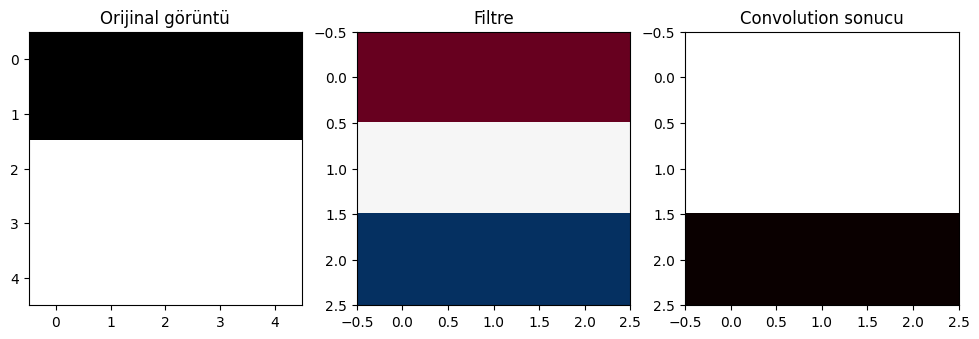

In [3]:
# ══════════════════════════════════════════════════════
# CONVOLUTION İŞLEMİ NEDİR?
# ══════════════════════════════════════════════════════
#
# Filtre (kernel) = küçük ağırlık matrisi (örn: 3x3)
# Görüntünün üzerinde kaydırılır
# Her konumda: filtre × görüntü bölgesi → tek sayı
#
# Örnek — kenar tespiti filtresi:
#   [[-1, -1, -1],
#    [ 0,  0,  0],
#    [ 1,  1,  1]]
#
# Bu filtre yatay kenarları bulur!
# Yukarısı karanlık, aşağısı aydınlık → büyük değer
# Yukarısı = aşağısı → küçük değer (kenar yok)
#
# CNN'de bu filtreler öğrenilir — elle yazmıyoruz!
# ══════════════════════════════════════════════════════

# Basit 5x5 görüntü
goruntu = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],   # ← burada yatay kenar var
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
], dtype=float)

# Yatay kenar filtresi (3x3)
filtre = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
], dtype=float)

print("Görüntü:")
print(goruntu)
print("\nFiltre (yatay kenar dedektörü):")
print(filtre)

# Convolution uygula
H, W = goruntu.shape
fH, fW = filtre.shape
sonuc = np.zeros((H - fH + 1, W - fW + 1))  # (3, 3)

for i in range(H - fH + 1):
    for j in range(W - fW + 1):
        # Görüntünün (i,j) bölgesini filtre ile çarp, topla
        bolge = goruntu[i:i+fH, j:j+fW]
        sonuc[i, j] = np.sum(bolge * filtre)

print("\nConvolution sonucu:")
print(sonuc)
print("\nEn büyük değer nerede? → Orada kenar var!")

# Görselleştir
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(goruntu, cmap='gray')
axes[0].set_title("Orijinal görüntü")
axes[1].imshow(filtre, cmap='RdBu')
axes[1].set_title("Filtre")
axes[2].imshow(sonuc, cmap='hot')
axes[2].set_title("Convolution sonucu")
plt.show()

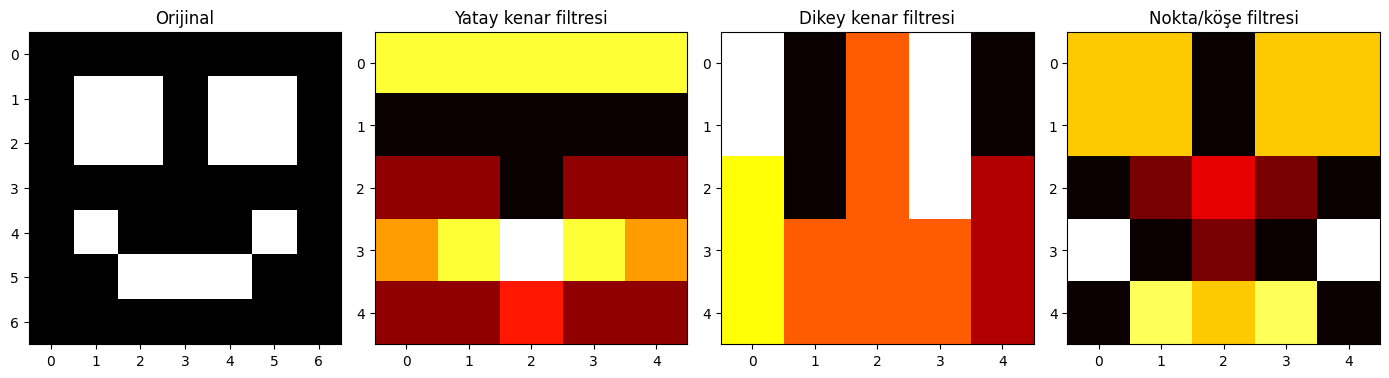

Her filtre farklı bir özellik yakaladı!
CNN'de bu filtreler OTOMATIK öğrenilir!


In [4]:
# ══════════════════════════════════════════════════════
# FARKLI FİLTRELER FARKLI ÖZELLİKLER ÖĞRENIR
# ══════════════════════════════════════════════════════
#
# CNN'de onlarca, yüzlerce filtre olur
# Her filtre farklı bir özellik öğrenir:
#   Filtre 1 → yatay kenarlar
#   Filtre 2 → dikey kenarlar
#   Filtre 3 → köşeler
#   Filtre 4 → renkler
#   ...
#   Derin katmanlarda → gözler, burunlar, kulaklar...
# ══════════════════════════════════════════════════════

# Daha gerçekçi görüntü — basit yüz gibi
goruntu = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0],   # gözler
    [0, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 1, 0],   # ağız köşeleri
    [0, 0, 1, 1, 1, 0, 0],   # ağız
    [0, 0, 0, 0, 0, 0, 0],
], dtype=float)

# 3 farklı filtre
filtre_yatay = np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=float)
filtre_dikey = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=float)
filtre_nokta = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]], dtype=float)

def conv2d(img, kernel):
    H, W = img.shape
    kH, kW = kernel.shape
    out = np.zeros((H-kH+1, W-kW+1))
    for i in range(H-kH+1):
        for j in range(W-kW+1):
            out[i,j] = np.sum(img[i:i+kH, j:j+kW] * kernel)
    return out

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(goruntu, cmap='gray')
axes[0].set_title("Orijinal")

axes[1].imshow(conv2d(goruntu, filtre_yatay), cmap='hot')
axes[1].set_title("Yatay kenar filtresi")

axes[2].imshow(conv2d(goruntu, filtre_dikey), cmap='hot')
axes[2].set_title("Dikey kenar filtresi")

axes[3].imshow(conv2d(goruntu, filtre_nokta), cmap='hot')
axes[3].set_title("Nokta/köşe filtresi")

plt.tight_layout()
plt.show()

print("Her filtre farklı bir özellik yakaladı!")
print("CNN'de bu filtreler OTOMATIK öğrenilir!")

In [5]:
# ══════════════════════════════════════════════════════
# CNN FORWARD PASS — TAM YAPI
# ══════════════════════════════════════════════════════
#
# Tam CNN yapısı:
#   Görüntü → Conv → ReLU → Pool → FC → Skor
#
# Pool (MaxPooling) nedir?
#   Görüntüyü küçültür
#   2x2 bölgeden en büyük değeri al
#   Parametre yok, sadece boyut küçültür
#
# Neden Pool?
#   "Kenar biraz sağda da olsa tanı"
#   Konum hassasiyetini azaltır
#   Hesaplama maliyetini düşürür
# ══════════════════════════════════════════════════════

def conv_forward(x, W, b, stride=1, pad=0):
    """
    x: girdi, shape (N, C, H, W)
    W: filtreler, shape (F, C, HH, WW)
    b: bias, shape (F,)
    """
    N, C, H, W_in = x.shape
    F, C, HH, WW = W.shape

    # Çıktı boyutu
    H_out = (H + 2*pad - HH) // stride + 1
    W_out = (W_in + 2*pad - WW) // stride + 1

    # Padding ekle
    x_pad = np.pad(x, ((0,0),(0,0),(pad,pad),(pad,pad)))

    out = np.zeros((N, F, H_out, W_out))

    for n in range(N):          # her görüntü
        for f in range(F):      # her filtre
            for i in range(H_out):
                for j in range(W_out):
                    # Görüntü bölgesi
                    bolge = x_pad[n, :, i*stride:i*stride+HH, j*stride:j*stride+WW]
                    out[n, f, i, j] = np.sum(bolge * W[f]) + b[f]

    cache = (x, W, b, stride, pad)
    return out, cache

def maxpool_forward(x, pool_size=2, stride=2):
    """
    2x2 bölgeden max değeri al → görüntüyü küçült
    """
    N, C, H, W = x.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    out = np.zeros((N, C, H_out, W_out))

    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    bolge = x[n, c, i*stride:i*stride+pool_size,
                                     j*stride:j*stride+pool_size]
                    out[n, c, i, j] = np.max(bolge)

    cache = (x, pool_size, stride)
    return out, cache

# Test edelim — 1 görüntü, 1 kanal, 6x6
np.random.seed(0)
x = np.random.randn(1, 1, 6, 6)  # (N, C, H, W)
W = np.random.randn(2, 1, 3, 3) * 0.1  # 2 filtre, 3x3
b = np.zeros(2)

print("Girdi shape:", x.shape)

# Conv
conv_out, _ = conv_forward(x, W, b, stride=1, pad=0)
print("Conv sonrası shape:", conv_out.shape)  # (1, 2, 4, 4)

# ReLU
relu_out = np.maximum(0, conv_out)
print("ReLU sonrası shape:", relu_out.shape)

# MaxPool
pool_out, _ = maxpool_forward(relu_out, pool_size=2, stride=2)
print("MaxPool sonrası shape:", pool_out.shape)  # (1, 2, 2, 2)

# Flatten → FC katmanına hazırla
flat = pool_out.reshape(1, -1)
print("Flatten sonrası shape:", flat.shape)

print("\nCNN pipeline:")
print(f"  Görüntü: {x.shape} → Conv: {conv_out.shape} → Pool: {pool_out.shape} → Flat: {flat.shape}")

Girdi shape: (1, 1, 6, 6)
Conv sonrası shape: (1, 2, 4, 4)
ReLU sonrası shape: (1, 2, 4, 4)
MaxPool sonrası shape: (1, 2, 2, 2)
Flatten sonrası shape: (1, 8)

CNN pipeline:
  Görüntü: (1, 1, 6, 6) → Conv: (1, 2, 4, 4) → Pool: (1, 2, 2, 2) → Flat: (1, 8)


In [6]:
# ══════════════════════════════════════════════════════
# TAM BAĞLANTILI vs CNN KARŞILAŞTIRMASI
# ══════════════════════════════════════════════════════
#
# Tam bağlantılı ağ:
#   Her nöron tüm piksellere bağlı
#   32x32 görüntü → 1024 parametre (sadece 1 nöron için!)
#
# CNN:
#   3x3 filtre → 9 parametre
#   Bu filtre tüm görüntüde paylaşılır!
#   Çok daha az parametre → daha verimli
#
# Parametre karşılaştırması:
# ══════════════════════════════════════════════════════

# 32x32 görüntü, 32 filtre varsayalım
goruntu_H, goruntu_W = 32, 32
kanal = 3
filtre_sayisi = 32
filtre_boyutu = 3

# FC katman parametre sayısı
fc_params = (goruntu_H * goruntu_W * kanal) * filtre_sayisi
print(f"Tam bağlantılı katman: {fc_params:,} parametre")
# 32x32x3 = 3072 girdi, 32 nöron → 3072 × 32 = 98.304

# CNN katman parametre sayısı
cnn_params = filtre_boyutu * filtre_boyutu * kanal * filtre_sayisi
print(f"CNN katmanı:           {cnn_params:,} parametre")
# 3×3×3 = 27 parametre/filtre × 32 filtre = 864

print(f"\nCNN {fc_params//cnn_params}x daha az parametre kullanıyor!")
print("Ama görüntü boyunca paylaşıldığı için daha güçlü!")

print("\n=== CNN vs FC ÖZET ===")
print(f"{'':20} {'FC':>15} {'CNN':>15}")
print(f"{'Parametre sayısı':20} {fc_params:>15,} {cnn_params:>15,}")
print(f"{'Konum bağımsız':20} {'❌':>15} {'✅':>15}")
print(f"{'Parametre paylaşımı':20} {'❌':>15} {'✅':>15}")
print(f"{'Görüntü için uygun':20} {'❌':>15} {'✅':>15}")

Tam bağlantılı katman: 98,304 parametre
CNN katmanı:           864 parametre

CNN 113x daha az parametre kullanıyor!
Ama görüntü boyunca paylaşıldığı için daha güçlü!

=== CNN vs FC ÖZET ===
                                  FC             CNN
Parametre sayısı              98,304             864
Konum bağımsız                     ❌               ✅
Parametre paylaşımı                ❌               ✅
Görüntü için uygun                 ❌               ✅


In [7]:
# ══════════════════════════════════════════════════════
# CNN ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║         CONVOLUTIONAL NEURAL NETWORK ÖZET        ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  Neden CNN?                                      ║")
print("║    FC ağda çok fazla parametre var               ║")
print("║    Görüntüdeki konumu bilmiyor                   ║")
print("║    CNN 113x daha az parametre kullanır           ║")
print("║                                                  ║")
print("║  CNN Yapısı:                                     ║")
print("║    Görüntü → Conv → ReLU → Pool → FC → Skor      ║")
print("║                                                  ║")
print("║  Conv katmanı:                                   ║")
print("║    Küçük filtreler (3x3, 5x5)                    ║")
print("║    Filtreler görüntü üzerinde kayar              ║")
print("║    Her filtre farklı özellik öğrenir             ║")
print("║    Kenarlar, köşeler, dokular...                 ║")
print("║                                                  ║")
print("║  MaxPool katmanı:                                ║")
print("║    Görüntüyü küçültür                            ║")
print("║    Konum hassasiyetini azaltır                   ║")
print("║    Parametre yok!                                ║")
print("║                                                  ║")
print("║  Derin CNN'lerde:                                ║")
print("║    İlk katmanlar → kenarlar, renkler             ║")
print("║    Orta katmanlar → şekiller, dokular            ║")
print("║    Son katmanlar → yüzler, nesneler              ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║         CONVOLUTIONAL NEURAL NETWORK ÖZET        ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  Neden CNN?                                      ║
║    FC ağda çok fazla parametre var               ║
║    Görüntüdeki konumu bilmiyor                   ║
║    CNN 113x daha az parametre kullanır           ║
║                                                  ║
║  CNN Yapısı:                                     ║
║    Görüntü → Conv → ReLU → Pool → FC → Skor      ║
║                                                  ║
║  Conv katmanı:                                   ║
║    Küçük filtreler (3x3, 5x5)                    ║
║    Filtreler görüntü üzerinde kayar              ║
║    Her filtre farklı özellik öğrenir             ║
║    Kenarlar, köşeler, dokular...                 ║
║                                                  ║
║  MaxPool katmanı:                           